# Spike Set Comparison

Compare two folders containing raw traces and spike detection results. The notebook loads `*_analyzed.npz` files, computes event dF/F (%), SNR, FWHM, and overlays spike waveforms using a publication-style bar/scatter and mean waveform layout.

In [1]:
# User settings
from pathlib import Path

# Set these to your two folders. Each folder can contain *_analyzed.npz directly or in spike_detection/.
FOLDER_A = Path('/Volumes/T7 Shield/20260630_rep_ASAP5')
FOLDER_B = Path('/Volumes/T7 Shield/20260630_rep_ASAP7')

GROUP_NAMES = ('ASAP5', 'ASAP7y')
COLORS = ('#19b5fe', '#f1c40f')
SPIKE_TYPES = ('SS', 'CS')

# Plot style: 'bar_scatter' follows the attached reference image; 'box' and 'violin' are also available.
PLOT_STYLE = 'bar_scatter'
P_VALUE_TEST = 'ttest'  # 'mannwhitney' or 'ttest'
BAR_DATAPOINT_LEVEL = 'cell'  # 'cell': one dot per cell mean; 'event': one dot per detected spike

# Trace/event measurement settings
NEGATIVE_GOING = True
# Match Spike Detector baseline correction: Median baseline with a 30 ms rolling window.
BASELINE_WINDOW_MS = 30.0
# ASAP signals are negative-going, so the displayed amplitude is -dF/F (%).
REPORT_NEGATIVE_AS_MINUS_DFF = True
WAVEFORM_WINDOWS_MS = {'SS': 30.0, 'CS': 30.0}
DOT_SIZE = 7.5  # point size for individual-spike dots in bar plots
SNR_NOISE_PRE_MS = {'SS': 50.0, 'CS': 150.0}
SNR_NOISE_GAP_MS = {'SS': 5.0, 'CS': 20.0}

OUTPUT_SUBFOLDER = 'comparison_figures'
DPI = 300

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import peak_widths
from scipy.ndimage import median_filter
from scipy import stats

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.linewidth'] = 1.6
mpl.rcParams['xtick.major.width'] = 1.4
mpl.rcParams['ytick.major.width'] = 1.4

def pick_folder(prompt):
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk(); root.withdraw(); root.update()
        path = filedialog.askdirectory(title=prompt)
        root.destroy()
        return Path(path) if path else Path('')
    except Exception:
        return Path(input(prompt + ': ').strip())

if not str(FOLDER_A):
    FOLDER_A = pick_folder('Select group A folder')
if not str(FOLDER_B):
    FOLDER_B = pick_folder('Select group B folder')

FOLDER_A = Path(FOLDER_A).expanduser()
FOLDER_B = Path(FOLDER_B).expanduser()
OUTPUT_DIR = FOLDER_A / OUTPUT_SUBFOLDER
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Group A:', FOLDER_A)
print('Group B:', FOLDER_B)
print('Output:', OUTPUT_DIR)

Group A: /Volumes/T7 Shield/20260630_rep_ASAP5
Group B: /Volumes/T7 Shield/20260630_rep_ASAP7
Output: /Volumes/T7 Shield/20260630_rep_ASAP5/comparison_figures


In [3]:
def robust_sigma(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.nanmedian(x)
    sig = 1.4826 * np.nanmedian(np.abs(x - med))
    return float(sig) if np.isfinite(sig) and sig > 0 else np.nan

def find_analyzed_files(folder):
    folder = Path(folder)
    files = sorted(folder.glob('*_analyzed.npz'))
    files += sorted((folder / 'spike_detection').glob('*_analyzed.npz'))
    return sorted(set(files))

def as_list_of_arrays(obj):
    arr = np.asarray(obj, dtype=object)
    if arr.ndim == 0:
        return [np.asarray(arr.item(), dtype=float)]
    return [np.asarray(x, dtype=float).ravel() for x in arr]

def load_npz(path):
    z = np.load(path, allow_pickle=True)
    return {k: z[k] for k in z.files}

def spike_detector_median_baseline(trace, fs, window_ms=30.0):
    x = np.asarray(trace, dtype=float)
    window_samples = int(float(window_ms) * float(fs) / 1000.0)
    max_samples_cap = max(5, min(len(x) // 2, 5000))
    window_samples = max(5, min(window_samples, max_samples_cap))
    return median_filter(x, size=int(window_samples))

def fwhm_ms(wave, fs):
    y = np.asarray(wave, dtype=float)
    if y.size < 5 or not np.any(np.isfinite(y)):
        return np.nan
    p = int(np.nanargmax(y))
    baseline = float(np.nanmedian(y[:max(3, min(p, int(0.1 * y.size)))])) if p > 0 else 0.0
    yy = y - baseline
    if not np.isfinite(yy[p]) or yy[p] <= 0:
        return np.nan
    try:
        widths, _, _, _ = peak_widths(yy, [p], rel_height=0.5)
        return float(widths[0] * 1000.0 / fs) if widths.size and widths[0] > 0 else np.nan
    except Exception:
        return np.nan

def reported_dff_percent(raw_value, baseline_value):
    f0 = float(baseline_value)
    if not np.isfinite(f0) or abs(f0) <= 1e-12:
        return np.nan
    dff = 100.0 * (float(raw_value) - f0) / abs(f0)
    return -dff if REPORT_NEGATIVE_AS_MINUS_DFF and NEGATIVE_GOING else dff

def waveform_reported_dff_percent(raw_wave, baseline_wave):
    raw_wave = np.asarray(raw_wave, dtype=float)
    baseline_wave = np.asarray(baseline_wave, dtype=float)
    denom = np.where(np.abs(baseline_wave) > 1e-12, np.abs(baseline_wave), np.nan)
    vals = 100.0 * (raw_wave - baseline_wave) / denom
    if REPORT_NEGATIVE_AS_MINUS_DFF and NEGATIVE_GOING:
        vals = -vals
    return vals

def spike_window_ms(spike_type):
    return float(WAVEFORM_WINDOWS_MS[str(spike_type).upper()])

def waveform_half_samples(spike_type, fs):
    return max(2, int(round((spike_window_ms(spike_type) / 2.0) * float(fs) / 1000.0)))

def waveform_target_samples(spike_type, fs):
    return 2 * waveform_half_samples(spike_type, fs) + 1

def center_crop_waveform(wave, spike_type, fs):
    ww = np.asarray(wave, dtype=float).ravel()
    target = waveform_target_samples(spike_type, fs)
    if ww.size <= target:
        return ww
    center = ww.size // 2
    half = target // 2
    start = max(0, center - half)
    end = start + target
    if end > ww.size:
        end = ww.size
        start = max(0, end - target)
    return ww[start:end]

def peak_index_for_spike(raw_trace, p0, pre, post):
    s = max(0, int(p0 - pre))
    e = min(len(raw_trace), int(p0 + post))
    if e <= s:
        return int(p0)
    local = np.asarray(raw_trace[s:e], dtype=float)
    return int(s + (np.nanargmin(local) if NEGATIVE_GOING else np.nanargmax(local)))

def finite_array(x):
    arr = np.asarray(x, dtype=float).ravel()
    return arr[np.isfinite(arr)]

def saved_metric_arrays(d, spike_type):
    st = str(spike_type).lower()
    suffix = 'cs' if st == 'cs' else 'ss'
    keys = {
        'minus_dff_percent': f'event_minus_dff_percent_{suffix}',
        'snr': f'event_snr_{suffix}',
        'fwhm_ms': f'event_fwhm_{suffix}',
        'waveforms': f'event_waveforms_minus_dff_percent_{suffix}',
    }
    if not all(k in d for k in keys.values()):
        return None
    return keys

def append_saved_events(path, group_name, spike_type, d, rows, waves):
    keys = saved_metric_arrays(d, spike_type)
    if keys is None:
        return False
    fs = float(np.asarray(d.get('fs', 1000.0)).ravel()[0])
    dff_cells = as_list_of_arrays(d[keys['minus_dff_percent']])
    snr_cells = as_list_of_arrays(d[keys['snr']])
    fwhm_cells = as_list_of_arrays(d[keys['fwhm_ms']])
    wave_cells = np.asarray(d[keys['waveforms']], dtype=object)
    n_cells = max(len(dff_cells), len(snr_cells), len(fwhm_cells))
    for ci in range(n_cells):
        dff = finite_array(dff_cells[ci]) if ci < len(dff_cells) else np.array([])
        snr = finite_array(snr_cells[ci]) if ci < len(snr_cells) else np.array([])
        fwhm = finite_array(fwhm_cells[ci]) if ci < len(fwhm_cells) else np.array([])
        n = max(len(dff), len(snr), len(fwhm))
        for j in range(n):
            rows.append({
                'group': group_name,
                'file': path.name,
                'cell': ci,
                'spike_type': str(spike_type).upper(),
                'minus_dff_percent': dff[j] if j < len(dff) else np.nan,
                'snr': snr[j] if j < len(snr) else np.nan,
                'fwhm_ms': fwhm[j] if j < len(fwhm) else np.nan,
                'metric_source': 'saved_spike_detector',
            })
        try:
            cell_waves = wave_cells[ci]
            for w in np.asarray(cell_waves, dtype=object):
                ww = center_crop_waveform(w, spike_type, fs)
                if ww.size > 3 and np.all(np.isfinite(ww)):
                    waves.append({'group': group_name, 'spike_type': str(spike_type).upper(), 'waveform': ww, 'metric_source': 'saved_spike_detector'})
        except Exception:
            pass
    return True

def extract_events_from_file_fallback(path, group_name, spike_type, d):
    spike_type = str(spike_type).upper()
    raw = np.asarray(d.get('processed_raw_data', d.get('raw_data', np.empty((0, 0)))), dtype=float)
    if raw.ndim != 2 or raw.size == 0:
        return [], []
    fs = float(np.asarray(d.get('fs', 1000.0)).ravel()[0])
    baseline_all = np.asarray(d.get('baseline_traces', np.empty((0, 0))), dtype=float)
    spike_key = 'spike_times_cs' if spike_type == 'CS' else 'spike_times_ss'
    trace_key = 'cs_traces' if spike_type == 'CS' else 'ss_traces'
    spike_times = as_list_of_arrays(d.get(spike_key, []))
    det_traces = as_list_of_arrays(d.get(trace_key, [])) if trace_key in d else []
    rows, waves = [], []
    pre = waveform_half_samples(spike_type, fs)
    post = pre + 1
    noise_pre = int(round(float(SNR_NOISE_PRE_MS[spike_type]) * fs / 1000.0))
    noise_gap = int(round(float(SNR_NOISE_GAP_MS[spike_type]) * fs / 1000.0))
    for ci in range(raw.shape[1]):
        raw_trace = np.asarray(raw[:, ci], dtype=float)
        if baseline_all.ndim == 2 and baseline_all.shape == raw.shape:
            baseline = baseline_all[:, ci]
        else:
            baseline = spike_detector_median_baseline(raw_trace, fs, BASELINE_WINDOW_MS)
        corrected_for_detection = baseline - raw_trace if NEGATIVE_GOING else raw_trace - baseline
        p_ms = spike_times[ci] if ci < len(spike_times) else np.array([])
        peaks = np.clip(np.rint(p_ms * fs / 1000.0).astype(int), 0, raw_trace.size - 1)
        fwhm_trace = np.asarray(det_traces[ci], dtype=float) if ci < len(det_traces) and np.asarray(det_traces[ci]).size == raw_trace.size else corrected_for_detection
        for p0 in peaks:
            if p0 - pre < 0 or p0 + post > raw_trace.size:
                continue
            peak_idx = peak_index_for_spike(raw_trace, p0, max(2, pre // 3), max(2, post // 3))
            dff_pct = reported_dff_percent(raw_trace[peak_idx], baseline[peak_idx])
            w_raw = raw_trace[p0 - pre:p0 + post].copy()
            w_base = baseline[p0 - pre:p0 + post].copy()
            w_pct = waveform_reported_dff_percent(w_raw, w_base)
            amp_for_snr = float(np.nanmax(corrected_for_detection[p0 - pre:p0 + post]))
            n0 = max(0, p0 - noise_pre)
            n1 = max(0, p0 - noise_gap)
            sigma = robust_sigma(corrected_for_detection[n0:n1])
            snr = amp_for_snr / sigma if np.isfinite(sigma) and sigma > 0 else np.nan
            fw = fwhm_ms(fwhm_trace[max(0, p0 - pre):min(fwhm_trace.size, p0 + post)], fs)
            rows.append({'group': group_name, 'file': path.name, 'cell': ci, 'spike_type': spike_type, 'minus_dff_percent': dff_pct, 'snr': snr, 'fwhm_ms': fw, 'metric_source': 'fallback_recomputed'})
            waves.append({'group': group_name, 'spike_type': spike_type, 'waveform': w_pct, 'metric_source': 'fallback_recomputed'})
    return rows, waves

def extract_events_from_file(path, group_name, spike_type):
    d = load_npz(path)
    rows, waves = [], []
    if append_saved_events(path, group_name, spike_type, d, rows, waves):
        return rows, waves
    return extract_events_from_file_fallback(path, group_name, spike_type, d)

def collect_group(folder, group_name):
    rows, waves = [], []
    files = find_analyzed_files(folder)
    if not files:
        raise FileNotFoundError(f'No *_analyzed.npz files found in {folder}')
    for fp in files:
        for spike_type in SPIKE_TYPES:
            r, w = extract_events_from_file(fp, group_name, spike_type)
            rows.extend(r); waves.extend(w)
    return rows, waves

rows_a, waves_a = collect_group(FOLDER_A, GROUP_NAMES[0])
rows_b, waves_b = collect_group(FOLDER_B, GROUP_NAMES[1])
df = pd.DataFrame(rows_a + rows_b)
waves = waves_a + waves_b
if 'metric_source' in df:
    display(df.groupby(['metric_source', 'spike_type', 'group'])[['minus_dff_percent', 'snr', 'fwhm_ms']].agg(['count', 'mean', 'std']))
else:
    display(df.groupby(['spike_type', 'group'])[['minus_dff_percent', 'snr', 'fwhm_ms']].agg(['count', 'mean', 'std']))

minus_dff_percent                       \
                                                   count       mean       std   
metric_source        spike_type group                                           
saved_spike_detector CS         ASAP5                 28   9.680215  1.936508   
                                ASAP7y                46  18.030721  5.049774   
                     SS         ASAP5                647   6.012826  2.750656   
                                ASAP7y               604   9.380745  1.775532   

                                         snr                     fwhm_ms  \
                                       count      mean       std   count   
metric_source        spike_type group                                      
saved_spike_detector CS         ASAP5     28  5.794766  2.175714      28   
                                ASAP7y    46  8.250041  3.150422      46   
                     SS         ASAP5    647  4.109749  1.169531     641   
                                ASAP7y   604  4.243658  1.224346     597   

                                                            
                                            mean       std  
metric_source        spike_type group                       
saved_spike_detector CS         ASAP5   6.457392  1.278574  
                                ASAP7y  5.971957  1.343334  
                     SS         ASAP5   1.109612  0.654728  
                                ASAP7y  1.438424  0.823563

minus_dff_percent                       \
                                                  count       mean       std   
bar_datapoint_level spike_type group                                           
cell                CS         ASAP5                  6   9.664962  1.348464   
                               ASAP7y                 6  18.711416  3.403901   
                    SS         ASAP5                  6   6.086844  0.311784   
                               ASAP7y                 6   9.362216  0.828041   

                                        snr                     fwhm_ms  \
                                      count      mean       std   count   
bar_datapoint_level spike_type group                                      
cell                CS         ASAP5      6  5.831437  1.660602       6   
                               ASAP7y     6  8.379326  1.612194       6   
                    SS         ASAP5      6  3.974613  0.508911       6   
                               ASAP7y     6  4.254481  0.444205       6   

                                                           
                                           mean       std  
bar_datapoint_level spike_type group                       
cell                CS         ASAP5   6.565607  0.822473  
                               ASAP7y  6.088486  0.600199  
                    SS         ASAP5   1.127437  0.163982  
                               ASAP7y  1.440386  0.222156

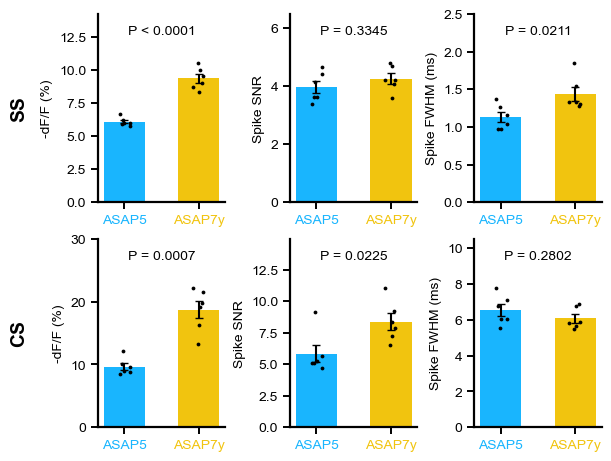

In [4]:
def p_value_text(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if a.size < 2 or b.size < 2:
        return 'n/a', np.nan
    if P_VALUE_TEST == 'ttest':
        p = stats.ttest_ind(a, b, equal_var=False, nan_policy='omit').pvalue
    else:
        p = stats.mannwhitneyu(a, b, alternative='two-sided').pvalue
    txt = 'P < 0.0001' if p < 1e-4 else f'P = {p:.4f}'
    return txt, float(p)

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=5, width=1.4)

def make_bar_plot_table(events_df):
    level = str(BAR_DATAPOINT_LEVEL).strip().lower()
    metrics_cols = ['minus_dff_percent', 'snr', 'fwhm_ms']
    if level in ('event', 'spike', 'spikes'):
        out = events_df.copy()
        out['bar_datapoint_level'] = 'event'
        return out
    if level not in ('cell', 'cells'):
        raise ValueError("BAR_DATAPOINT_LEVEL must be 'cell' or 'event'.")
    group_cols = ['group', 'spike_type', 'file', 'cell']
    out = events_df.groupby(group_cols, as_index=False)[metrics_cols].mean(numeric_only=True)
    counts = events_df.groupby(group_cols, as_index=False).size().rename(columns={'size': 'n_spikes'})
    out = out.merge(counts, on=group_cols, how='left')
    out['bar_datapoint_level'] = 'cell'
    return out

def plot_metric(ax, data, metric, ylabel):
    vals = [data.loc[data.group == g, metric].dropna().to_numpy(dtype=float) for g in GROUP_NAMES]
    x = np.arange(2)
    means = [np.nanmean(v) if v.size else np.nan for v in vals]
    sems = [stats.sem(v, nan_policy='omit') if v.size > 1 else 0 for v in vals]
    if PLOT_STYLE == 'box':
        bp = ax.boxplot(vals, positions=x, widths=0.5, patch_artist=True, showfliers=False)
        for patch, c in zip(bp['boxes'], COLORS): patch.set_facecolor(c); patch.set_alpha(0.8)
    elif PLOT_STYLE == 'violin':
        vp = ax.violinplot(vals, positions=x, widths=0.55, showmeans=True, showextrema=False)
        for body, c in zip(vp['bodies'], COLORS): body.set_facecolor(c); body.set_edgecolor('none'); body.set_alpha(0.75)
    else:
        ax.bar(x, means, yerr=sems, color=COLORS, edgecolor='none', width=0.55, capsize=3, zorder=1)
    rng = np.random.default_rng(1)
    for i, v in enumerate(vals):
        if v.size:
            jitter = rng.uniform(-0.09, 0.09, size=v.size)
            ax.scatter(np.full(v.size, x[i]) + jitter, v, s=DOT_SIZE, color='black', linewidth=0, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_NAMES)
    for tick, c in zip(ax.get_xticklabels(), COLORS): tick.set_color(c)
    ax.set_ylabel(ylabel)
    style_axes(ax)
    ymax = np.nanmax(np.concatenate([v for v in vals if v.size])) if any(v.size for v in vals) else 1
    ax.set_ylim(0, ymax * 1.35 if ymax > 0 else 1)
    txt, _ = p_value_text(vals[0], vals[1])
    y = ymax * 1.18 if ymax > 0 else 0.8
    ax.text(0.5, y, txt, ha='center', va='bottom')

metrics = [('minus_dff_percent', '-dF/F (%)'), ('snr', 'Spike SNR'), ('fwhm_ms', 'Spike FWHM (ms)')]
bar_df = make_bar_plot_table(df)
display(bar_df.groupby(['bar_datapoint_level', 'spike_type', 'group'])[['minus_dff_percent', 'snr', 'fwhm_ms']].agg(['count', 'mean', 'std']))
fig, axes = plt.subplots(len(SPIKE_TYPES), len(metrics), figsize=(6.0, 2.25 * len(SPIKE_TYPES)), constrained_layout=True)
axes = np.atleast_2d(axes)
for row, spike_type in enumerate(SPIKE_TYPES):
    sub = bar_df[bar_df.spike_type == str(spike_type).upper()]
    for col, (metric, ylabel) in enumerate(metrics):
        plot_metric(axes[row, col], sub, metric, ylabel)
    axes[row, 0].text(-0.55, 0.5, str(spike_type).upper(), transform=axes[row, 0].transAxes,
                      ha='right', va='center', fontsize=14, fontweight='bold', rotation=90, clip_on=False)
for ext in ('svg', 'png'):
    fig.savefig(OUTPUT_DIR / f'ss_cs_comparison_metrics.{ext}', dpi=DPI)
plt.show()


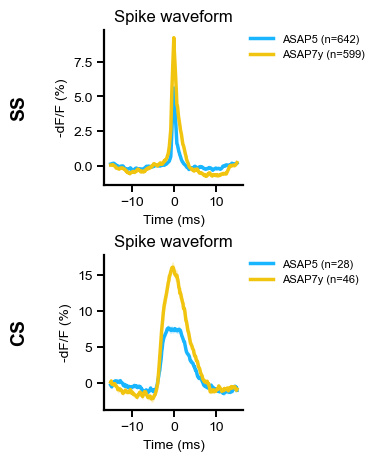

In [5]:
def stack_waveforms(group, spike_type):
    arr = [np.asarray(w['waveform'], dtype=float) for w in waves if w['group'] == group and w['spike_type'] == str(spike_type).upper()]
    arr = [x for x in arr if x.size > 3 and np.all(np.isfinite(x))]
    if not arr:
        return np.empty((0, 0))
    n = min(x.size for x in arr)
    return np.vstack([x[:n] for x in arr])

fig, axes = plt.subplots(len(SPIKE_TYPES), 1, figsize=(3.6, 2.25 * len(SPIKE_TYPES)), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, spike_type in zip(axes, SPIKE_TYPES):
    spike_type = str(spike_type).upper()
    for group, color in zip(GROUP_NAMES, COLORS):
        stack = stack_waveforms(group, spike_type)
        if stack.size == 0:
            continue
        window_ms = spike_window_ms(spike_type)
        x = np.linspace(-window_ms / 2.0, window_ms / 2.0, stack.shape[1])
        mean = np.nanmean(stack, axis=0)
        sem = stats.sem(stack, axis=0, nan_policy='omit') if stack.shape[0] > 1 else np.zeros_like(mean)
        ax.plot(x, mean, color=color, lw=2.5, label=f'{group} (n={stack.shape[0]})')
        ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.25, linewidth=0)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('-dF/F (%)')
    ax.set_title('Spike waveform')
    ax.text(-0.55, 0.5, spike_type, transform=ax.transAxes, ha='right', va='center',
            fontsize=14, fontweight='bold', rotation=90, clip_on=False)
    style_axes(ax)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0, frameon=False, fontsize=8)
for ext in ('svg', 'png'):
    fig.savefig(OUTPUT_DIR / f'ss_cs_waveform_overlay.{ext}', dpi=DPI, bbox_inches='tight')
plt.show()

In [6]:
event_csv = OUTPUT_DIR / 'ss_cs_event_metrics.csv'
df.to_csv(event_csv, index=False)
if 'bar_df' in globals():
    plot_csv = OUTPUT_DIR / f"ss_cs_{str(BAR_DATAPOINT_LEVEL).strip().lower()}_plot_metrics.csv"
    bar_df.to_csv(plot_csv, index=False)
    print('Saved plotted metrics CSV:', plot_csv)
print('Saved event metrics CSV:', event_csv)
print('Saved figures in:', OUTPUT_DIR)


Saved plotted metrics CSV: /Volumes/T7 Shield/20260630_rep_ASAP5/comparison_figures/ss_cs_cell_plot_metrics.csv
Saved event metrics CSV: /Volumes/T7 Shield/20260630_rep_ASAP5/comparison_figures/ss_cs_event_metrics.csv
Saved figures in: /Volumes/T7 Shield/20260630_rep_ASAP5/comparison_figures
